In [1]:
import os
import cv2
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Twoje moduły
from software._load_image import load_image
from software.masks.generate import create_mask_from_json
from software.preprocessing.image_aligner.straighten_image import straighten_image
from software.preprocessing.image_aligner.detection import extract_long_lines, filter_horizontal_lines
from software.preprocessing.image_aligner.geometry import calculate_alpha, rad_to_deg
from software.preprocessing.image_aligner.transform import rotate_image_full_alpha
from software.evaluate.scoring import calculate_dataset_score, load_predictions_for_scoring

# Konfiguracja
TRAIN_DIR = 'data/val/'
VAL_DIR = 'data/val/'
IMG_SIZE = (512, 512)
BATCH_SIZE = 8
EPOCHS = 10 # Zwiększamy, aby model "zaskoczył"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def dice_loss(pred, target, smooth=1.):
    intersection = (pred * target).sum(dim=(2, 3))
    loss = (1 - ((2. * intersection + smooth) / (pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + smooth)))
    return loss.mean()

In [2]:
class ECGDataset(Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.json_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.json')])

    def __len__(self): return len(self.json_files)

    def __getitem__(self, idx):
        json_p = os.path.join(self.data_dir, self.json_files[idx])
        base_name = self.json_files[idx].replace('.json', '')
        img_p = os.path.join(self.data_dir, base_name + '.png')
        if not os.path.exists(img_p): img_p = os.path.join(self.data_dir, base_name + '.jpg')

        img_raw = load_image(img_p)
        _, lines = extract_long_lines(img_raw)
        filtered = filter_horizontal_lines(lines)
        angle = rad_to_deg(calculate_alpha(filtered)) if filtered else 0.0

        # Prostowanie i konwersja do RGB
        img_straight = straighten_image(img_raw)
        if img_straight.shape[2] == 4:
            img_straight = cv2.cvtColor(img_straight, cv2.COLOR_RGBA2RGB)

        # Maska z Twojego skryptu i jej wyprostowanie
        mask_raw = create_mask_from_json(json_p, img_raw.shape, apply_angle=angle)
        m_3ch = cv2.cvtColor(mask_raw, cv2.COLOR_GRAY2RGB)
        m_straight = rotate_image_full_alpha(m_3ch, angle)[:,:,0]

        img_in = cv2.resize(img_straight, IMG_SIZE) / 255.0
        mask_in = (cv2.resize(m_straight, IMG_SIZE, interpolation=cv2.INTER_NEAREST) > 127).astype(np.float32)

        return (torch.tensor(img_in).permute(2,0,1).float(),
                torch.tensor(mask_in).unsqueeze(0), base_name, img_straight.shape[:2])

In [3]:
class LiteUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1 = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.Conv2d(32, 32, 3, padding=1), nn.ReLU())
        self.pool = nn.MaxPool2d(2)
        self.e2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU())
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.d1 = nn.Sequential(nn.Conv2d(64 + 32, 32, 3, padding=1), nn.ReLU())
        self.out = nn.Sequential(nn.Conv2d(32, 1, 1), nn.Sigmoid())

    def forward(self, x):
        x1 = self.e1(x)
        x2 = self.e2(self.pool(x1))
        x = self.up(x2)
        x = torch.cat([x, x1], dim=1) # Łączymy cechy z enkodera (detale linii)
        return self.out(self.d1(x))

model = LiteUNet().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=0.0005) # Nieco mniejszy LR dla stabilności
bce_loss = nn.BCELoss()

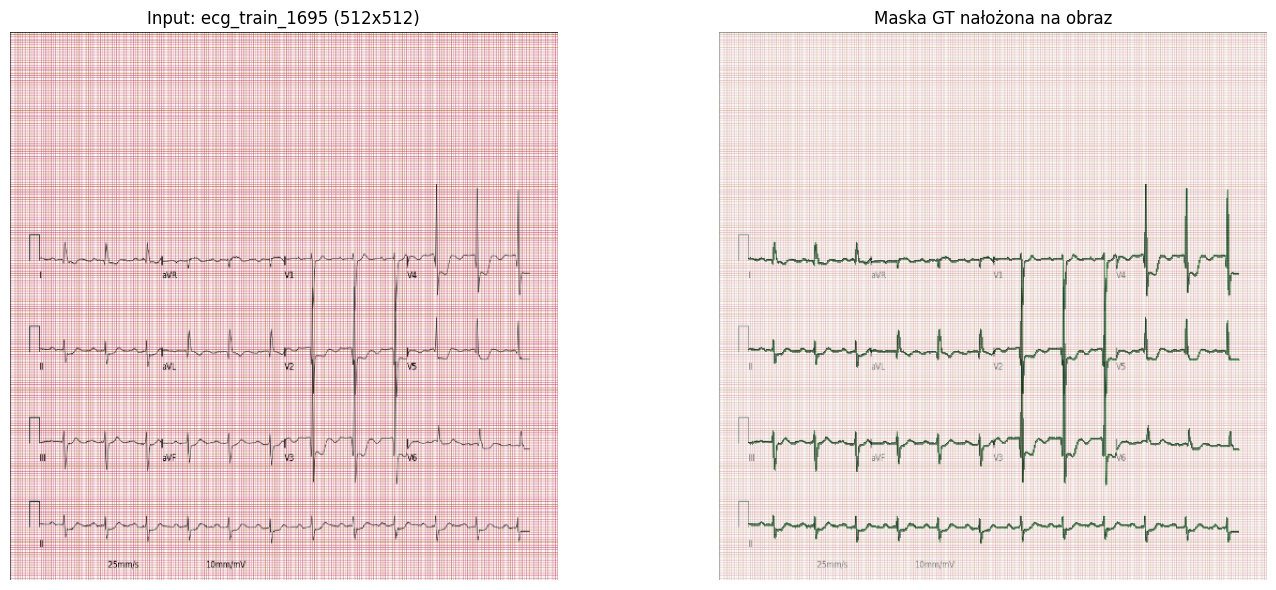

Rozmiar oryginalny: 924x714
Suma pikseli maski: 9508.0


In [4]:
import matplotlib.pyplot as plt

# Pobieramy jedną paczkę danych
test_loader = DataLoader(ECGDataset(TRAIN_DIR), batch_size=1, shuffle=True)
img_t, mask_t, name_t, dims_t = next(iter(test_loader))

# Konwersja do formatu czytelnego dla matplotlib
img_vis = img_t[0].permute(1, 2, 0).numpy()
mask_vis = mask_t[0, 0].numpy()

plt.figure(figsize=(15, 6))

# 1. Oryginalny obraz (zeskalowany do 512x512)
plt.subplot(1, 2, 1)
plt.imshow(img_vis)
plt.title(f"Input: {name_t[0]} (512x512)")
plt.axis('off')

# 2. Nałożenie maski na obraz
plt.subplot(1, 2, 2)
plt.imshow(img_vis)
plt.imshow(mask_vis, alpha=0.5, cmap='Greens') # Maska na czerwono
plt.title("Maska GT nałożona na obraz")
plt.axis('off')

plt.tight_layout()
plt.show()

# Szybki test jakości
print(f"Rozmiar oryginalny: {dims_t[1].item()}x{dims_t[0].item()}")
print(f"Suma pikseli maski: {mask_vis.sum()}")
if mask_vis.sum() < 100:
    print("UWAGA: Maska jest prawie pusta! Sprawdź generowanie masek.")

In [5]:
train_loader = DataLoader(ECGDataset(TRAIN_DIR), batch_size=BATCH_SIZE, shuffle=True)

for epoch in range(EPOCHS):
    model.train()
    pbar = tqdm(train_loader, desc=f"Epoka {epoch+1}/{EPOCHS}")
    for imgs, masks, _, _ in pbar:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        # Mix strat: Dice dla balansu klas, BCE dla dokładności pikseli
        loss = dice_loss(outputs, masks) + bce_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

Epoka 1/10:   0%|          | 0/25 [00:00<?, ?it/s]

Epoka 2/10:   0%|          | 0/25 [00:00<?, ?it/s]

Epoka 3/10:   0%|          | 0/25 [00:00<?, ?it/s]

Epoka 4/10:   0%|          | 0/25 [00:00<?, ?it/s]

Epoka 5/10:   0%|          | 0/25 [00:00<?, ?it/s]

Epoka 6/10:   0%|          | 0/25 [00:00<?, ?it/s]

Epoka 7/10:   0%|          | 0/25 [00:00<?, ?it/s]

Epoka 8/10:   0%|          | 0/25 [00:00<?, ?it/s]

Epoka 9/10:   0%|          | 0/25 [00:00<?, ?it/s]

Epoka 10/10:   0%|          | 0/25 [00:00<?, ?it/s]

Rozpoczynam digitalizację...


Digitalizacja:   0%|          | 0/200 [00:00<?, ?it/s]

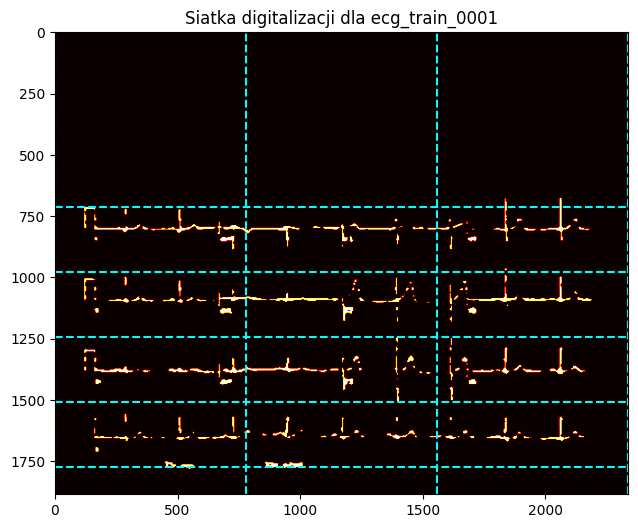

Zapisano 2400 sygnałów do submission.npz


In [14]:
import numpy as np
import cv2
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# --- KONFIGURACJA ---
val_loader = DataLoader(ECGDataset(VAL_DIR), batch_size=1)
submission = {}
model.eval()

DPI, P_S, GAIN, FS = 200, 25, 10, 500
PX_PER_MM = DPI / 25.4

# Układ 12 odprowadzeń (3 kolumny x 4 rzędy)
LEAD_GRID = [
    ["I", "aVR", "V1"],
    ["II", "aVL", "V2"],
    ["III", "aVF", "V3"],
    ["V4", "V5", "V6"]
]

print("Rozpoczynam digitalizację...")
with torch.no_grad():
    for i, (img, _, name, dims) in enumerate(tqdm(val_loader, desc="Digitalizacja")):
        real_name = name[0]
        pred = model(img.to(DEVICE))[0, 0].cpu().numpy()
        h, w = dims[0].item(), dims[1].item()

        # Maska (threshold 0.5)
        mask = cv2.resize((pred > 0.5).astype(np.uint8), (w, h))

        # Znajdowanie aktywnego obszaru (pomiń puste marginesy)
        y_sums = mask.sum(axis=1)
        active_y = np.where(y_sums > (w * 0.01))[0]
        if len(active_y) == 0: continue

        y_start, y_end = active_y[0], active_y[-1]
        row_h = (y_end - y_start) // 4
        col_w = w // 3

        # Wyliczamy czas trwania JEDNEGO segmentu (jednej kolumny)
        segment_dur = col_w / (PX_PER_MM * P_S)
        target_len = int(segment_dur * FS)

        # Podgląd siatki dla pierwszego obrazu
        if i == 0:
            plt.figure(figsize=(15, 6))
            plt.imshow(mask, cmap='hot')
            for r in range(5): plt.axhline(y_start + r*row_h, color='cyan', ls='--')
            for c in range(4): plt.axvline(c*col_w, color='cyan', ls='--')
            plt.title(f"Siatka digitalizacji dla {real_name}")
            plt.show()

        # Ekstrakcja 12 odprowadzeń
        for r_idx in range(4):
            for c_idx in range(3):
                y1, y2 = y_start + r_idx * row_h, y_start + (r_idx + 1) * row_h
                x1, x2 = c_idx * col_w, (c_idx + 1) * col_w

                cell_mask = mask[y1:y2, x1:x2]
                lead_name = LEAD_GRID[r_idx][c_idx]

                sig = []
                for x in range(cell_mask.shape[1]):
                    y_pts = np.where(cell_mask[:, x] > 0)[0]
                    if len(y_pts) > 0:
                        # Pozycja Y względem środka obrazu
                        actual_y = y_pts.mean() + y1
                        val = (h/2 - actual_y) / (PX_PER_MM * GAIN)
                        sig.append(val)
                    else:
                        sig.append(0.0)

                # Resampling do 500 Hz (target_len próbek)
                x_old = np.linspace(0, segment_dur, len(sig))
                x_new = np.linspace(0, segment_dur, target_len)
                f_i = interp1d(x_old, sig, fill_value="extrapolate")

                lead_key = f"{real_name}_{lead_name}"
                submission[lead_key] = f_i(x_new).astype(np.float16)

# Zapis do pliku
np.savez_compressed('submission.npz', **submission)
print(f"Zapisano {len(submission)} sygnałów do submission.npz")

In [18]:
import json
import os
from scipy.interpolate import interp1d
from tqdm.auto import tqdm

# --- WCZYTYWANIE GROUND TRUTH ---
dataset_true = {}
PX_PER_MM = DPI / 25.4

# Używamy VAL_DIR, aby porównywać te same pliki, które digitalizowaliśmy
for f in tqdm(os.listdir(VAL_DIR), desc="Budowanie bazy GT"):
    if f.endswith('.json'):
        with open(os.path.join(VAL_DIR, f), 'r') as jf:
            d = json.load(jf)
            h_o, w_o, rid = d['height'], d['width'], f.replace('.json', '')

            # Kluczowe: czas segmentu musi być taki sam jak w digitalizacji (1/3 szerokości)
            segment_width = w_o / 3
            segment_dur = segment_width / (PX_PER_MM * P_S)
            target_len = int(segment_dur * FS)

            for l in d['leads']:
                pix = np.array(l['plotted_pixels'])
                if pix.size == 0: continue

                # Konwersja pikseli na mV
                y_mv = (h_o/2 - pix[:, 0]) / (PX_PER_MM * GAIN)

                # Resampling do target_len (500 Hz)
                x_old = np.linspace(0, segment_dur, len(y_mv))
                x_new = np.linspace(0, segment_dur, target_len)
                f_i = interp1d(x_old, y_mv, fill_value="extrapolate")

                # Klucz: ID_NAZWA (np. ecg_train_0001_V2)
                dataset_true[f"{rid}_{l['lead_name']}"] = f_i(x_new)

# --- URUCHOMIENIE SCORINGU ---
try:
    dataset_pred = load_predictions_for_scoring('submission.npz')

    # Szybki debug spójności
    test_key = list(dataset_true.keys())[0]
    print(f"\nDEBUG: Przykładowy klucz: {test_key}")
    print(f"Długość GT: {len(dataset_true[test_key])} | Długość Pred: {len(dataset_pred.get(test_key, []))}")

    score = calculate_dataset_score(dataset_true, dataset_pred)

    print("\n--- RAPORT KOŃCOWY ---")
    if isinstance(score, dict):
        for k, v in score.items():
            print(f"{k:20}: {v:.4f}")
    else:
        print(f"Total Dataset Score: {score:.4f}")

except Exception as e:
    print(f"\nBłąd podczas scoringu: {e}")

Budowanie bazy GT:   0%|          | 0/800 [00:00<?, ?it/s]


DEBUG: Przykładowy klucz: ecg_train_0001_III
Długość GT: 1862 | Długość Pred: 0

--- RAPORT KOŃCOWY ---
Total Dataset Score: 0.0000
